<div style="text-align:center;">
  <h1 size=10>
    <b>MLOps PROJECT</b><br>
    <b></b>
  </h1>
</div>

<h2 style="text-align:center;">
Master's in Data Science and Advanced Analytics - NOVA IMS (25/26)
</h2>

**Group ??**
- Bárbara Franco (20250388)
- Catarina Aboim (20250375)
- Catarina Mendinhas (20250422)
- Maria Miguel Fonseca (20250380)

**GitHub repository:**

<font color='#2f94d7' size=6>**TABLE OF CONTENTS**</font> <a class="anchor" id='toc'></a>

- [1. Project Overview](#1)
- [2. Set Up & Import Libraries](#2)
- [3. Load Data](#3)
- [4. Metadata](#4)
- [5. Data Exploration](#5)

# <font color='#2f94d7' size=6>**1. Project Overview**</font> <a class="anchor" id="1"></a>

[Back to TOC](#toc)

# <font color='#2f94d7' size=6>**2. Set Up & Import Libraries**</font> <a class="anchor" id="2"></a>

[Back to TOC](#toc)

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import chi2_contingency

# <font color='#2f94d7' size=6>**3. Load Data**</font> <a class="anchor" id="3"></a>

[Back to TOC](#toc)

In [6]:
df_train = pd.read_csv('../data/01_raw/portugal_listings.csv')

/var/folders/m2/bxrs057j70l7nzx_qpwm8m9w0000gn/T/ipykernel_74983/1761435925.py:1: DtypeWarning: Columns (9,10,12,13,14,15,16,20) have mixed types. Specify dtype option on import or set low_memory=False.
  df_train = pd.read_csv('../data/01_raw/portugal_listings.csv')


# <font color='#2f94d7' size=6>**4. Data Type Correction**</font> <a class="anchor" id="3"></a>

[Back to TOC](#toc)

In [7]:
df_train['PublishDate'] = pd.to_datetime(df_train['PublishDate'], errors='coerce')

# <font color='#2f94d7' size=6>**5. Metadata**</font> <a class="anchor" id="4"></a>

[Back to TOC](#toc)

- `Price:` The asking price of the property in Euros.

- `District, City, Town:` The geographical location of the property, allowing for regional analysis.
- `Type:` The type of property (e.g., Apartment, House, Garage, Land).
- `EnergyCertificate:` The energy efficiency rating of the property, according to Portuguese energy certification standards.
- **Area Measurements:** Several columns related to the size and area of the property, including:
    - `GrossPrivateArea:` The private gross area of the property.
    - `UsableArea:` The area that can be used for living.
    - `LivingArea:` The actual livable space inside the property.
    - `LotSize:` The size of the land associated with the property.
    - `BuiltArea:` The total constructed area of the property.
- `Rooms, Bedrooms, Bathrooms, WCs:` Detailed breakdowns of the number of rooms, bedrooms, bathrooms, and water closets in the property.
- `Floor:` The floor on which the property is located.
- `Parking, Garage:` Information on parking availability and the presence of a garage.
- `Additional Features:` Whether the property includes amenities like elevators or electric car charging stations.
- `ConstructionYear:` The year the property was built.
- `PublishDate:` The date when the listing was published.

## Metadata das Colunas

| Coluna | Grupo | Tipo | Descrição |
|--------|-------|------|-----------|
| `Price` | Preço | float | Preço de venda pedido pelo imóvel, em Euros (€). |
| `District` | Localização | string | Distrito onde o imóvel está localizado (nível administrativo mais alto em Portugal). |
| `City` | Localização | string | Concelho (município) onde o imóvel se encontra. |
| `Town` | Localização | string | Freguesia ou localidade específica dentro do concelho. |
| `Type` | Tipologia | string | Tipo de imóvel (ex: Apartamento, Moradia, Garagem, Terreno). |
| `EnergyCertificate` | Energia | string | Certificação energética do imóvel segundo as normas portuguesas (ex: A+, A, B, B-, C, D, E, F). Valor em bruto tal como publicado no anúncio. |
| `EnergyEfficiencyLevel` | Energia | int / ordinal | Nível de eficiência energética codificado numericamente a partir do `EnergyCertificate` (ex: 1 = A+, 7 = F). Facilita ordenação e análise quantitativa. Coluna derivada. |
| `GrossArea` | Área | float (m²) | Área bruta privativa do imóvel em m², incluindo paredes e áreas de uso exclusivo do proprietário. Corresponde à `GrossPrivateArea` do site de origem. |
| `TotalArea` | Área | float (m²) | Área total associada ao imóvel em m², podendo incluir áreas comuns ou dependências (garagem, arrecadação). Corresponde à `UsableArea` do site de origem. |
| `LivingArea` | Área | float (m²) | Área habitável interior do imóvel em m², excluindo paredes e espaços não habitáveis. |
| `LotSize` | Área | float (m²) | Área total do terreno associado ao imóvel em m². Relevante sobretudo para moradias e terrenos. |
| `BuiltArea` | Área | float (m²) | Área total construída do imóvel em m², incluindo todas as estruturas edificadas no terreno. |
| `TotalRooms` | Divisões | int | Número total de divisões do imóvel (inclui quartos, salas e outros espaços habitáveis). |
| `NumberOfBedrooms` | Divisões | int | Número de quartos de dormir do imóvel. |
| `NumberOfWC` | Divisões | int | Número de WCs (casas de banho sem banheira/duche, apenas sanita e lavatório). |
| `NumberOfBathrooms` | Divisões | int | Número de casas de banho completas (com banheira ou duche). |
| `Floor` | Características | int / string | Piso em que o imóvel se encontra (ex: 0 = rés-do-chão, valores negativos para cave). |
| `Parking` | Características | int | Número de lugares de estacionamento associados ao imóvel. |
| `HasParking` | Características | bool | Indica se o imóvel tem lugar(es) de estacionamento (True/False). Coluna derivada de `Parking`. |
| `Garage` | Características | bool | Indica se o imóvel dispõe de garagem fechada (True/False), distinta de simples lugar de estacionamento. |
| `Elevator` | Características | bool | Indica se o edifício dispõe de elevador (True/False). |
| `ElectricCarsCharging` | Características | bool | Indica se o imóvel ou edifício possui carregador para veículos elétricos (True/False). |
| `ConservationStatus` | Características | string | Estado de conservação do imóvel (ex: Novo, Em bom estado, Para recuperar, Em construção). |
| `ConstructionYear` | Características | int | Ano de construção do imóvel. |
| `PublishDate` | Administração | date | Data em que o anúncio foi publicado na plataforma (formato YYYY-MM-DD). |

In [8]:
#'Price', 'District', 'City', 'Town', 'Type', 'EnergyCertificate',
#       'GrossArea', 'TotalArea', 'Parking', 'HasParking', 'Floor',
#       'ConstructionYear', 'EnergyEfficiencyLevel', 'PublishDate', 'Garage',
#       'Elevator', 'ElectricCarsCharging', 'TotalRooms', 'NumberOfBedrooms',
#       'NumberOfWC', 'ConservationStatus', 'LivingArea', 'LotSize',
#       'BuiltArea', 'NumberOfBathrooms'

# <font color='#2f94d7' size=6>**6. Data Exploration**</font> <a class="anchor" id="4"></a>

[Back to TOC](#toc)

In [9]:
df_train.shape

(135536, 25)

In [10]:
df_train.head()

,Price,District,City,Town,Type,EnergyCertificate,GrossArea,TotalArea,Parking,HasParking,...,Elevator,ElectricCarsCharging,TotalRooms,NumberOfBedrooms,NumberOfWC,ConservationStatus,LivingArea,LotSize,BuiltArea,NumberOfBathrooms
0,780000.0,Vila Real,Valpaços,Carrazedo de Montenegro e Curros,Farm,NC,200.0,552450.0,0.0,False,...,False,NaN,NaN,NaN,NaN,NaN,120.0,NaN,NaN,0.0
1,223000.0,Faro,São Brás de Alportel,São Brás de Alportel,Apartment,A+,NaN,81.0,1.0,True,...,True,NaN,2.0,NaN,NaN,NaN,81.0,NaN,NaN,2.0
2,228000.0,Faro,São Brás de Alportel,São Brás de Alportel,Apartment,A+,NaN,108.0,1.0,True,...,True,NaN,2.0,NaN,NaN,NaN,108.0,NaN,NaN,2.0
3,250000.0,Faro,São Brás de Alportel,São Brás de Alportel,Apartment,A+,NaN,114.0,1.0,True,...,True,NaN,2.0,NaN,NaN,NaN,114.0,NaN,NaN,0.0
4,250000.0,Faro,São Brás de Alportel,São Brás de Alportel,Apartment,A+,NaN,114.0,1.0,True,...,True,NaN,2.0,NaN,NaN,NaN,114.0,NaN,NaN,2.0


In [11]:
df_train.tail()

,Price,District,City,Town,Type,EnergyCertificate,GrossArea,TotalArea,Parking,HasParking,...,Elevator,ElectricCarsCharging,TotalRooms,NumberOfBedrooms,NumberOfWC,ConservationStatus,LivingArea,LotSize,BuiltArea,NumberOfBathrooms
135531,130000.0,Setúbal,Palmela,Palmela,Land,NC,NaN,1189.0,0.0,NaN,...,False,False,NaN,NaN,0.0,NaN,NaN,1189.0,NaN,0.0
135532,45000.0,Viana do Castelo,Ponte de Lima,Labruja,House,NC,NaN,374.0,1.0,NaN,...,False,False,NaN,0.0,0.0,NaN,374.0,4370.0,NaN,0.0
135533,349900.0,Vila Real,Valpaços,Valpaços e Sanfins,House,F,NaN,188.0,1.0,NaN,...,False,False,NaN,3.0,1.0,NaN,190.0,18240.0,238.0,3.0
135534,50000.0,Vila Real,Alijó,Castedo e Cotas,House,NC,NaN,69.0,1.0,NaN,...,False,False,NaN,2.0,1.0,NaN,84.0,NaN,84.5,2.0
135535,35000.0,Vila Real,Valpaços,Algeriz,Land,NC,NaN,100.0,0.0,NaN,...,False,False,NaN,NaN,0.0,NaN,NaN,100.0,NaN,0.0


In [12]:
df_train.columns

Index(['Price', 'District', 'City', 'Town', 'Type', 'EnergyCertificate',
       'GrossArea', 'TotalArea', 'Parking', 'HasParking', 'Floor',
       'ConstructionYear', 'EnergyEfficiencyLevel', 'PublishDate', 'Garage',
       'Elevator', 'ElectricCarsCharging', 'TotalRooms', 'NumberOfBedrooms',
       'NumberOfWC', 'ConservationStatus', 'LivingArea', 'LotSize',
       'BuiltArea', 'NumberOfBathrooms'],
      dtype='object')

In [13]:
categorical_features = df_train.select_dtypes(include=['object']).columns
print("Categorical features:")
print(categorical_features)

Categorical features:
Index(['District', 'City', 'Town', 'Type', 'EnergyCertificate', 'HasParking',
       'Floor', 'EnergyEfficiencyLevel', 'Garage', 'Elevator',
       'ElectricCarsCharging', 'ConservationStatus'],
      dtype='object')


In [14]:
numeric_features = df_train.select_dtypes(include=['number']).columns
print("Numeric features:")
print(numeric_features)

Numeric features:
Index(['Price', 'GrossArea', 'TotalArea', 'Parking', 'ConstructionYear',
       'TotalRooms', 'NumberOfBedrooms', 'NumberOfWC', 'LivingArea', 'LotSize',
       'BuiltArea', 'NumberOfBathrooms'],
      dtype='object')


In [15]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135536 entries, 0 to 135535
Data columns (total 25 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   Price                  135236 non-null  float64       
 1   District               135536 non-null  object        
 2   City                   135536 non-null  object        
 3   Town                   135534 non-null  object        
 4   Type                   135520 non-null  object        
 5   EnergyCertificate      135522 non-null  object        
 6   GrossArea              27638 non-null   float64       
 7   TotalArea              127153 non-null  float64       
 8   Parking                135342 non-null  float64       
 9   HasParking             68215 non-null   object        
 10  Floor                  27929 non-null   object        
 11  ConstructionYear       88021 non-null   float64       
 12  EnergyEfficiencyLevel  67289 non-null   obje

In [16]:
df_train[numeric_features].describe()

,Price,GrossArea,TotalArea,Parking,ConstructionYear,TotalRooms,NumberOfBedrooms,NumberOfWC,LivingArea,LotSize,BuiltArea,NumberOfBathrooms
count,1.352360e+05,2.763800e+04,1.271530e+05,135342.000000,88021.000000,73244.000000,47041.000000,57256.000000,1.049520e+05,3.958300e+04,2.661700e+04,128700.000000
mean,3.681374e+05,2.789733e+03,5.140780e+05,0.549667,1989.303825,3.229357,2.665823,0.430785,1.403037e+03,5.636939e+04,3.086621e+03,1.544025
std,3.804044e+06,1.153670e+05,1.722937e+08,0.839257,26.684309,10.516977,1.790474,1.016360,3.474597e+04,5.208474e+06,1.185137e+05,1.764637
min,1.000000e+00,-7.000000e+00,-7.196067e+06,0.000000,1900.000000,0.000000,0.000000,-15.000000,0.000000e+00,0.000000e+00,-1.000000e+00,-13.000000
25%,8.400000e+04,1.000000e+02,9.100000e+01,0.000000,1973.000000,2.000000,2.000000,0.000000,8.000000e+01,2.580000e+02,1.045700e+02,0.000000
50%,2.100000e+05,1.640000e+02,1.590000e+02,0.000000,1994.000000,3.000000,3.000000,0.000000,1.180000e+02,6.790000e+02,1.680000e+02,1.000000
75%,3.950000e+05,2.940000e+02,5.000000e+02,1.000000,2009.000000,4.000000,3.000000,1.000000,2.040000e+02,2.890000e+03,3.000000e+02,2.000000
max,1.380000e+09,1.275000e+07,6.142007e+10,3.000000,2025.000000,2751.000000,21.000000,59.000000,5.429000e+06,9.923010e+08,1.275000e+07,131.000000


In [17]:
df_train[categorical_features].describe()

,District,City,Town,Type,EnergyCertificate,HasParking,Floor,EnergyEfficiencyLevel,Garage,Elevator,ElectricCarsCharging,ConservationStatus
count,135536,135536,135534,135520,135522,68215,27929,67289,67289,135504,67289,19292
unique,27,275,2263,21,12,2,19,11,2,2,2,6
top,Lisboa,Lisboa,Paranhos,Apartment,NC,False,Ground Floor,NC,False,False,False,New
freq,31351,8396,2228,47378,61387,37370,6973,31316,55594,102567,60863,6688


In [18]:
df_train.duplicated().sum()

np.int64(9011)

In [19]:
print("The percentage of duplicated that would be deleted is: {:.2f}%".format(df_train.duplicated().sum() / len(df_train) * 100))

The percentage of duplicated that would be deleted is: 6.65%


In [20]:
print(df_train.isnull().sum())
print()
print(f"Total missing values: {df_train.isna().sum().sum()}")

Price                       300
District                      0
City                          0
Town                          2
Type                         16
EnergyCertificate            14
GrossArea                107898
TotalArea                  8383
Parking                     194
HasParking                67321
Floor                    107607
ConstructionYear          47515
EnergyEfficiencyLevel     68247
PublishDate              106757
Garage                    68247
Elevator                     32
ElectricCarsCharging      68247
TotalRooms                62292
NumberOfBedrooms          88495
NumberOfWC                78280
ConservationStatus       116244
LivingArea                30584
LotSize                   95953
BuiltArea                108919
NumberOfBathrooms          6836
dtype: int64

Total missing values: 1238383


In [21]:
print("The percentage of missing values that would be deleted is: {:.2f}%".format(df_train.isnull().sum().sum() / df_train.size * 100))

The percentage of missing values that would be deleted is: 36.55%


In [22]:
for column in df_train.columns:
    unique_values = df_train[column].unique()
    print(f"Unique values on the column '{column}': {unique_values}")
    print('-----------------------------------')
    print('')


Unique values on the column 'Price': [780000. 223000. 228000. ... 890200. 912500. 605500.]
-----------------------------------

Unique values on the column 'District': ['Vila Real' 'Faro' 'Leiria' 'Porto' 'Lisboa' 'Guarda' 'Viseu' 'Setúbal'
 'Coimbra' 'Castelo Branco' 'Ilha Terceira' 'Beja' 'Santarém' 'Aveiro'
 'Évora' 'Braga' 'Ilha de São Miguel' 'Portalegre' 'Bragança'
 'Viana do Castelo' 'Ilha da Madeira' 'Ilha de Porto Santo'
 'Ilha de Santa Maria' 'Ilha de São Jorge' 'Z - Fora de Portugal'
 'Ilha do Faial' 'Ilha das Flores']
-----------------------------------

Unique values on the column 'City': ['Valpaços' 'São Brás de Alportel' 'Albufeira' 'Castro Marim' 'Portimão'
 'Loulé' 'Vila do Bispo' 'Olhão' 'Faro' 'Lagos' 'Peniche'
 'Vila Real de Santo António' 'Alcoutim' 'Lagoa (Algarve)' 'Silves'
 'Aljezur' 'Tavira' 'Porto' 'Monchique' 'Sintra' 'Seia'
 'Paços de Ferreira' 'Manteigas' 'Figueira de Castelo Rodrigo' 'Tondela'
 'Trancoso' 'Gouveia' 'Vila Nova de Foz Côa' 'Guarda' 'Almeida'

In [23]:
for column in df_train.select_dtypes(include=['number']).columns:
    count_values = df_train[column].value_counts()
    print(f"The number of the distinct values in the column '{column}' is: \n{count_values}")
    print('-----------------------------------')
    print('')

The number of the distinct values in the column 'Price' is: 
Price
150000.0     1364
350000.0     1272
35000.0      1270
250000.0     1248
45000.0      1118
             ... 
146289.0        1
539500.0        1
817000.0        1
1584000.0       1
605500.0        1
Name: count, Length: 4754, dtype: int64
-----------------------------------

The number of the distinct values in the column 'GrossArea' is: 
GrossArea
0.0        329
100.0      212
90.0       206
80.0       203
105.0      201
          ... 
5420.0       1
30600.0      1
3077.0       1
19985.0      1
2365.0       1
Name: count, Length: 2267, dtype: int64
-----------------------------------

The number of the distinct values in the column 'TotalArea' is: 
TotalArea
100.0      1187
80.0       1105
120.0      1091
90.0       1054
89.0       1052
           ... 
3953.0        1
16658.0       1
31052.0       1
82700.0       1
51020.0       1
Name: count, Length: 7305, dtype: int64
-----------------------------------

The number of

## Cheeking for Outliers

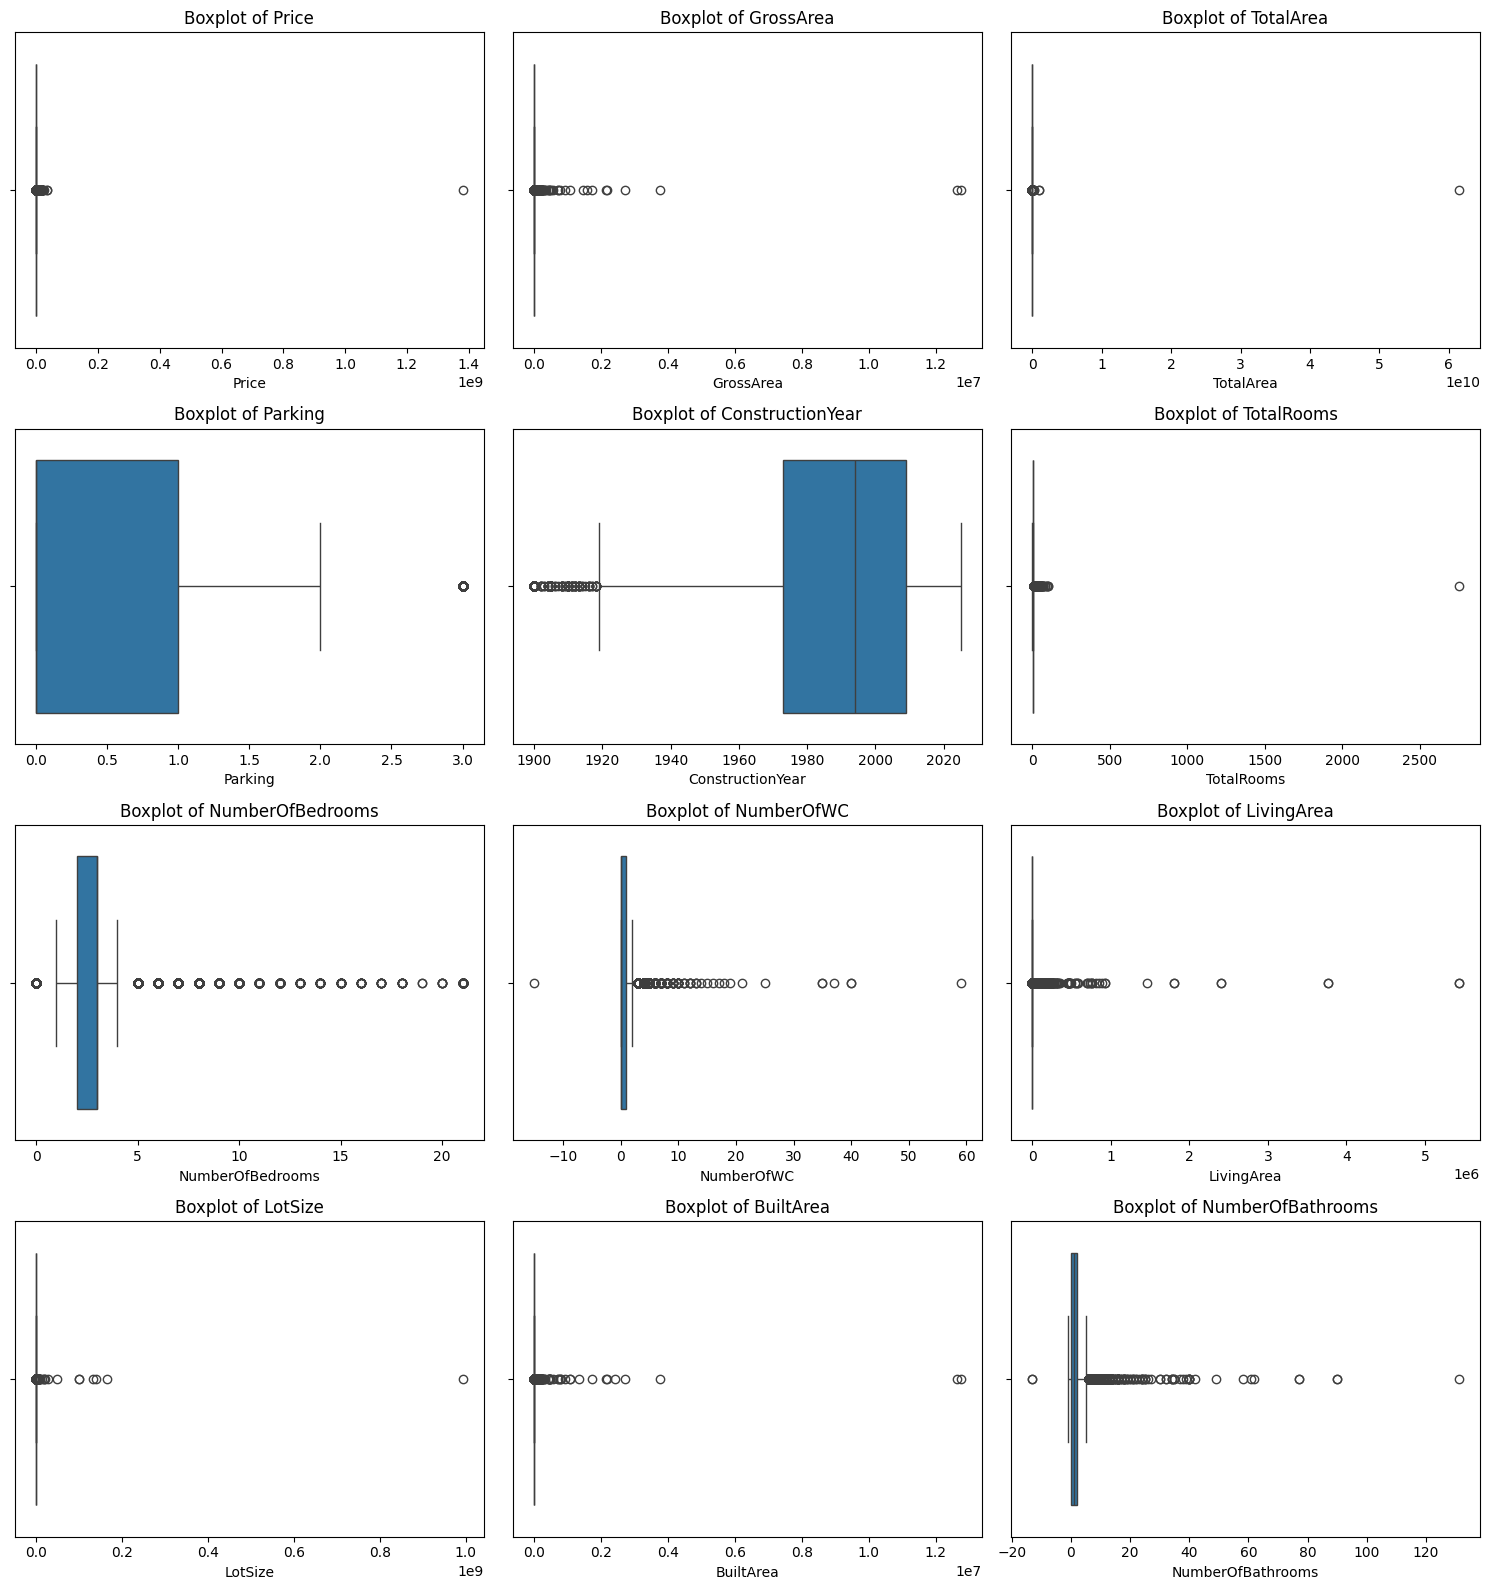

In [24]:
# see the boxplot of the numeric features
n_cols = 3
n_rows = -(-len(numeric_features) // n_cols)  # ceiling division

plt.figure(figsize=(15, n_rows * 4))
for i, column in enumerate(numeric_features):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(x=df_train[column])
    plt.title(f'Boxplot of {column}')
plt.tight_layout()
plt.show()

In [25]:
# check the index of the max of each numeric feature
for column in numeric_features:
    max_index = df_train[column].idxmax()
    print(f"The index of the max value in the column '{column}' is: {max_index}")

The index of the max value in the column 'Price' is: 58787
The index of the max value in the column 'GrossArea' is: 14782
The index of the max value in the column 'TotalArea' is: 73736
The index of the max value in the column 'Parking' is: 7
The index of the max value in the column 'ConstructionYear' is: 129201
The index of the max value in the column 'TotalRooms' is: 87191
The index of the max value in the column 'NumberOfBedrooms' is: 70399
The index of the max value in the column 'NumberOfWC' is: 94955
The index of the max value in the column 'LivingArea' is: 15329
The index of the max value in the column 'LotSize' is: 79564
The index of the max value in the column 'BuiltArea' is: 73400
The index of the max value in the column 'NumberOfBathrooms' is: 135169


In [ ]:
max_indices = [df_train[column].idxmax() for column in numeric_features]
unique_max_indices = set(max_indices) 
percentage_loss = len(unique_max_indices) / len(df_train) * 100
print(f"Percentage of data loss if we drop all rows with max values: {percentage_loss:.2f}%")

Percentage of data loss if we drop all rows with max values: 0.01%


## Target Variable Analysis (Price)

In [26]:
price = df_train['Price']
print(price.describe())
print('\nSkew    :', round(price.skew(), 2))
print('Kurtosis:', round(price.kurt(), 2))
print('Price <= 1 EUR     :', int((price <= 1).sum()))
print('Price < 5 000 EUR  :', int((price < 5_000).sum()))
print('Price > 5 000 000  :', int((price > 5_000_000).sum()))

count    1.352360e+05
mean     3.681374e+05
std      3.804044e+06
min      1.000000e+00
25%      8.400000e+04
50%      2.100000e+05
75%      3.950000e+05
max      1.380000e+09
Name: Price, dtype: float64

Skew    : 352.81
Kurtosis: 127935.61
Price <= 1 EUR     : 1
Price < 5 000 EUR  : 1166
Price > 5 000 000  : 299


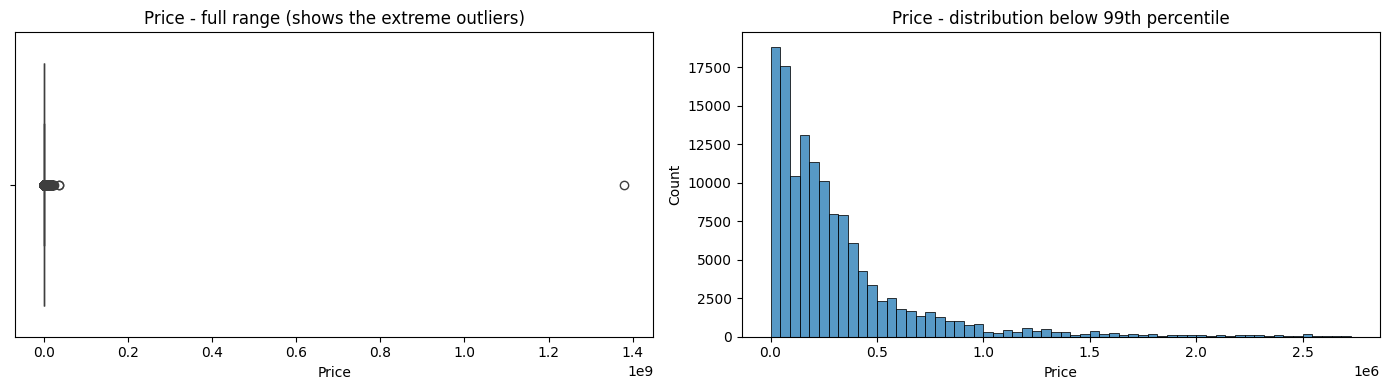

In [30]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.boxplot(x=price, ax=ax[0])
ax[0].set_title('Price - full range (shows the extreme outliers)')
sns.histplot(price[price < price.quantile(0.99)], bins=60, ax=ax[1])
ax[1].set_title('Price - distribution below 99th percentile')
plt.tight_layout(); plt.show()

**Conclusion:** The distribution is strongly right-skewed: most listings fall below ~500 000 €, with a long tail of high-value properties and at least one clearly corrupt value (~1.38 billion €) visible inthe boxplot. The realistic price range only becomes readable once the extreme outliers are set aside. These extreme values will be addressed later during the data preprocessing phase, and the skew suggests a log transform of the target is worth testing.

## Data Quality & Impossible Values

The raw `describe()` showed a minimum Price of 1€, a max of 1.38 **billion**€, and **negative areas** (GrossArea min −7, TotalArea min −7.2 million). These are corrupt records, not statistical outliers.

In [31]:
checks = {
    'Price <= 0'                 : df_train['Price'] <= 0,
    'Price == 1'                 : df_train['Price'] == 1,
    'GrossArea < 0'              : df_train['GrossArea'] < 0,
    'TotalArea < 0'              : df_train['TotalArea'] < 0,
    'LivingArea < 0'             : df_train['LivingArea'] < 0,
    'BuiltArea < 0'              : df_train['BuiltArea'] < 0,
    'LotSize < 0'                : df_train['LotSize'] < 0,
    'ConstructionYear > 2026'    : df_train['ConstructionYear'] > 2026,
    'ConstructionYear < 1800'    : df_train['ConstructionYear'] < 1800,
}
for name, mask in checks.items():
    print(f'{name:28s}: {int(mask.fillna(False).sum()):>7d}')

Price <= 0                  :       0
Price == 1                  :       1
GrossArea < 0               :       2
TotalArea < 0               :       7
LivingArea < 0              :       0
BuiltArea < 0               :       1
LotSize < 0                 :       0
ConstructionYear > 2026     :       0
ConstructionYear < 1800     :       0


In [33]:
checks = {
    # --- Impossible: logically cannot be true ---
    'Price <= 0'                 : df_train['Price'] <= 0,
    'GrossArea < 0'              : df_train['GrossArea'] < 0,
    'TotalArea < 0'              : df_train['TotalArea'] < 0,
    'LivingArea < 0'             : df_train['LivingArea'] < 0,
    'BuiltArea < 0'              : df_train['BuiltArea'] < 0,
    'LotSize < 0'                : df_train['LotSize'] < 0,
    'NumberOfWC < 0'             : df_train['NumberOfWC'] < 0,
    'NumberOfBathrooms < 0'      : df_train['NumberOfBathrooms'] < 0,
    'NumberOfBedrooms < 0'       : df_train['NumberOfBedrooms'] < 0,
    'TotalRooms < 0'             : df_train['TotalRooms'] < 0,
    'Parking < 0'                : df_train['Parking'] < 0,
    'ConstructionYear > 2026'    : df_train['ConstructionYear'] > 2026,
    'ConstructionYear < 1800'    : df_train['ConstructionYear'] < 1800,

    # --- Implausible: almost certainly corrupt (thresholds to tune later) ---
    'Price == 1'                 : df_train['Price'] == 1,
    'NumberOfBedrooms > 20'      : df_train['NumberOfBedrooms'] > 20,
    'NumberOfBathrooms > 20'     : df_train['NumberOfBathrooms'] > 20,
    'NumberOfWC > 20'            : df_train['NumberOfWC'] > 20,
    'TotalRooms > 50'            : df_train['TotalRooms'] > 50,
}

for name, mask in checks.items():
    print(f'{name:28s}: {int(mask.fillna(False).sum()):>7d}')

Price <= 0                  :       0
GrossArea < 0               :       2
TotalArea < 0               :       7
LivingArea < 0              :       0
BuiltArea < 0               :       1
LotSize < 0                 :       0
NumberOfWC < 0              :       1
NumberOfBathrooms < 0       :       3
NumberOfBedrooms < 0        :       0
TotalRooms < 0              :       0
Parking < 0                 :       0
ConstructionYear > 2026     :       0
ConstructionYear < 1800     :       0
Price == 1                  :       1
NumberOfBedrooms > 20       :      63
NumberOfBathrooms > 20      :      42
NumberOfWC > 20             :       8
TotalRooms > 50             :      22


### Investigating the extreme values further

In [34]:
big = df_train[(df_train['NumberOfBedrooms'] > 20) |
               (df_train['NumberOfBathrooms'] > 20) |
               (df_train['TotalRooms'] > 50)]
print('Rows flagged:', len(big))
print(big['Type'].value_counts())
big[['Type','Price','TotalRooms','NumberOfBedrooms','NumberOfBathrooms','GrossArea']].sort_values(
    'TotalRooms', ascending=False).head(20)

Rows flagged: 93
Type
Building               29
Hotel                  22
Farm                    8
House                   8
Other - Commercial      7
Land                    7
Investment              4
Manor                   2
Other - Residential     2
Apartment               2
Warehouse               1
Garage                  1
Name: count, dtype: int64


,Type,Price,TotalRooms,NumberOfBedrooms,NumberOfBathrooms,GrossArea
87191,House,56000.0,2751.0,1.0,0.0,NaN
118159,Garage,750000.0,100.0,NaN,NaN,NaN
128792,Building,950000.0,100.0,NaN,0.0,NaN
126043,Hotel,6800000.0,97.0,21.0,90.0,NaN
86144,Hotel,6800000.0,97.0,21.0,90.0,NaN
102893,Other - Commercial,1900000.0,80.0,NaN,77.0,NaN
120371,Other - Commercial,1900000.0,80.0,NaN,77.0,NaN
135015,Building,6900000.0,70.0,21.0,30.0,NaN
113904,Hotel,4500000.0,70.0,21.0,NaN,NaN
120217,Hotel,NaN,67.0,NaN,0.0,NaN


# <font color='#2f94d7' size=6>**Missing Values**</font>

[Back to TOC](#toc)

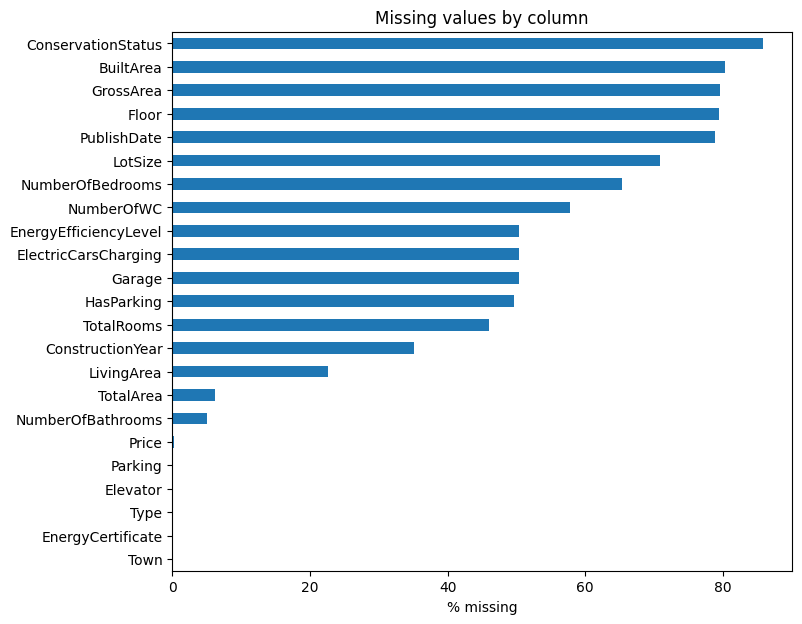

In [35]:
miss = (df_train.isna().mean() * 100).sort_values(ascending=False)
miss = miss[miss > 0]
plt.figure(figsize=(8, 7))
miss.plot.barh()
plt.gca().invert_yaxis()
plt.xlabel('% missing'); plt.title('Missing values by column'); plt.show()

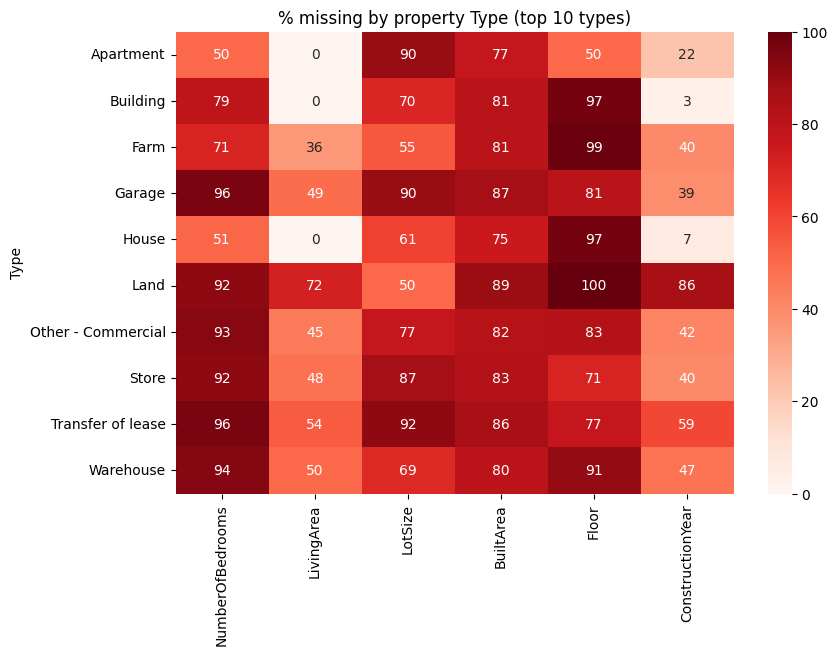

In [36]:
cols = ['NumberOfBedrooms', 'LivingArea', 'LotSize', 'BuiltArea', 'Floor', 'ConstructionYear']
top_types = df_train['Type'].value_counts().head(10).index
miss_by_type = (df_train[df_train['Type'].isin(top_types)]
                .groupby('Type')[cols]
                .apply(lambda g: g.isna().mean() * 100)
                .round(0))

plt.figure(figsize=(9, 6))
sns.heatmap(miss_by_type, annot=True, fmt='.0f', cmap='Reds')
plt.title('% missing by property Type (top 10 types)'); plt.show()

## Categorical Variables Exploration

In [37]:
cat_cols  = ['Type', 'EnergyCertificate', 'ConservationStatus', 'District', 'City', 'Town']
bool_cols = ['HasParking', 'Garage', 'Elevator', 'ElectricCarsCharging']

# Cardinality overview
for c in cat_cols:
    print(f'{c:18s}: {df_train[c].nunique()} categories')

Type              : 21 categories
EnergyCertificate : 12 categories
ConservationStatus: 6 categories
District          : 27 categories
City              : 275 categories
Town              : 2263 categories


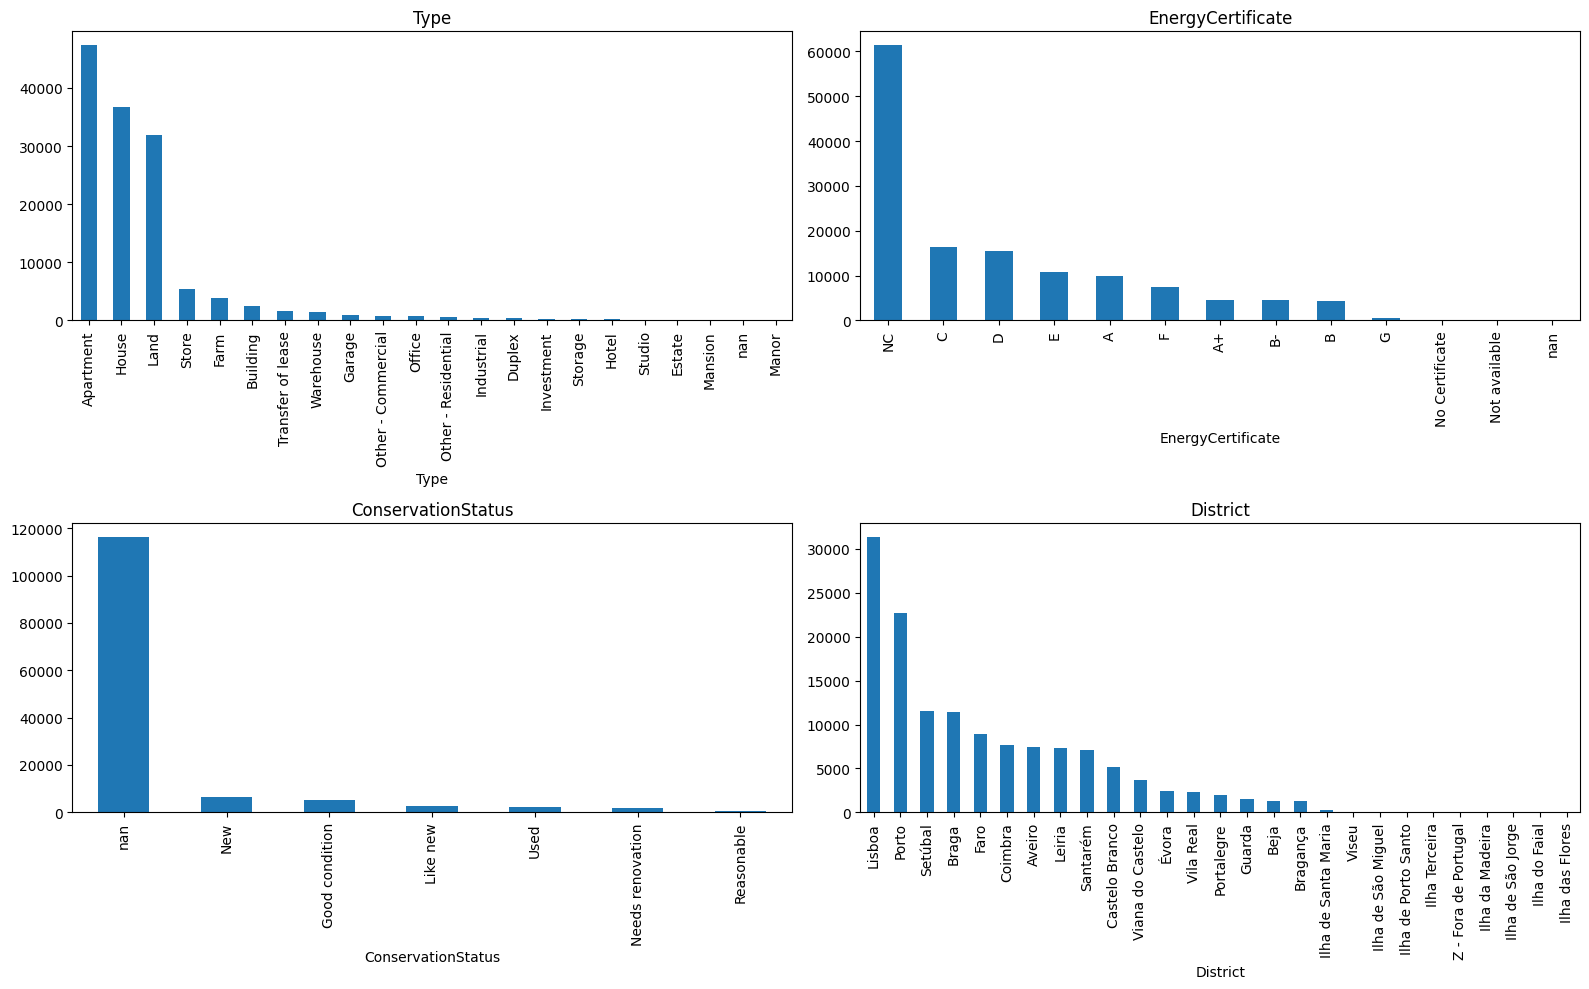

In [38]:
# Low-cardinality categoricals -> bar charts
plot_cols = ['Type', 'EnergyCertificate', 'ConservationStatus', 'District']
fig, ax = plt.subplots(2, 2, figsize=(16, 10))
for a, c in zip(ax.flat, plot_cols):
    df_train[c].value_counts(dropna=False).plot.bar(ax=a)
    a.set_title(c)
plt.tight_layout(); plt.show()

In [39]:
# Booleans -> value counts (include NA, since several are ~50% missing)
for c in bool_cols:
    print(c)
    print(df_train[c].value_counts(dropna=False), '\n')

HasParking
HasParking
NaN      67321
False    37370
True     30845
Name: count, dtype: int64 

Garage
Garage
NaN      68247
False    55594
True     11695
Name: count, dtype: int64 

Elevator
Elevator
False    102567
True      32937
NaN          32
Name: count, dtype: int64 

ElectricCarsCharging
ElectricCarsCharging
NaN      68247
False    60863
True      6426
Name: count, dtype: int64 



In [40]:
# High-cardinality geography -> top 10 only
for c in ['City', 'Town']:
    print(f'Top 10 {c}:')
    print(df_train[c].value_counts().head(10), '\n')

Top 10 City:
City
Lisboa               8396
Sintra               5527
Porto                5446
Vila Nova de Gaia    4281
Cascais              3236
Braga                2625
Oeiras               2251
Coimbra              2206
Loures               2076
Guimarães            1996
Name: count, dtype: int64 

Top 10 Town:
Town
Paranhos                                                           2228
Cascais e Estoril                                                  1459
Albufeira e Olhos de Água                                          1433
Cedofeita, Santo Ildefonso, Sé, Miragaia, São Nicolau e Vitória    1069
Portimão                                                           1054
Quarteira                                                           889
Canidelo                                                            858
Algés, Linda-a-Velha e Cruz Quebrada-Dafundo                        851
Montijo e Afonsoeiro                                                768
Arroios                     

# <font color='#2f94d7' size=6>**Temporal Analysis (PublishDate)**</font>

[Back to TOC](#toc)

Listings with a date: 28779 (21.2%)
Date range: 2018-04-09 05:48:21.907000 -> 2025-01-28 19:07:18.900000


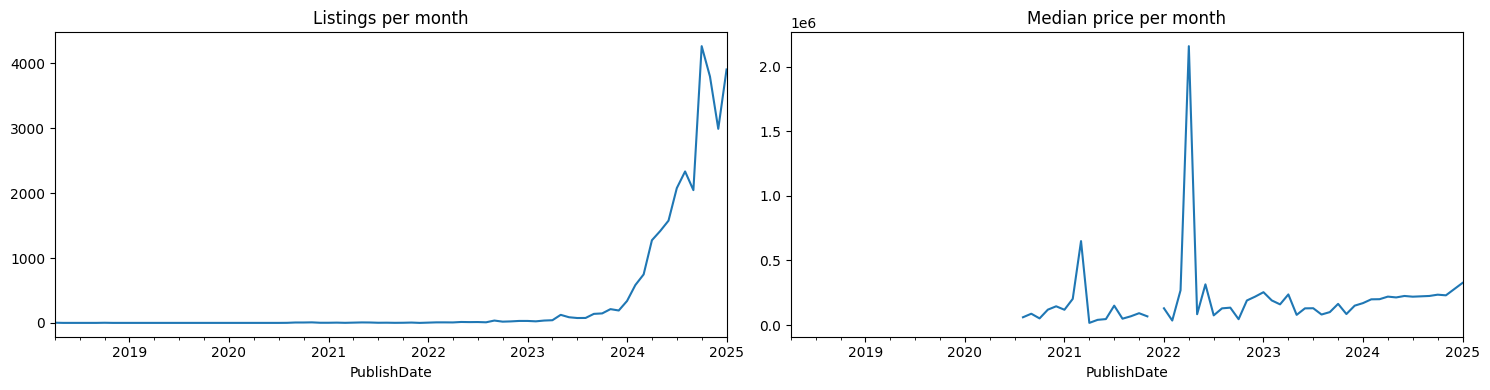

In [41]:
dated = df_train.dropna(subset=['PublishDate'])
print('Listings with a date:', len(dated), f'({len(dated)/len(df_train)*100:.1f}%)')
print('Date range:', dated['PublishDate'].min(), '->', dated['PublishDate'].max())

monthly = (dated.set_index('PublishDate')
           .resample('ME')
           .agg(n=('Price', 'size'), median_price=('Price', 'median')))
fig, ax = plt.subplots(1, 2, figsize=(15, 4))
monthly['n'].plot(ax=ax[0], title='Listings per month')
monthly['median_price'].plot(ax=ax[1], title='Median price per month')
plt.tight_layout(); plt.show()

**Conclusion** 

PublishDate is present for only 21% of listings and is heavily concentrated in 2024–2025; the steep rise in listings-per-month reflects scraping volume rather than market activity, so PublishDate behaves like a capture timestamp, not a true publication timeline. The price spikes in 2021–2022 coincide with near-empty months and are small-sample noise, not real market movements. Where data is dense (2023 onward) median price is stable with mild upward drift. 

Implications: 
- (1) data drift should be evaluated via biased/simulated samples rather than temporally 
- (2) PublishDate is not a reliable feature and should be excluded from modelling later down the data preprocessing.

## Relationships between variables

Rows in sane subset: 132544 (97.8%)


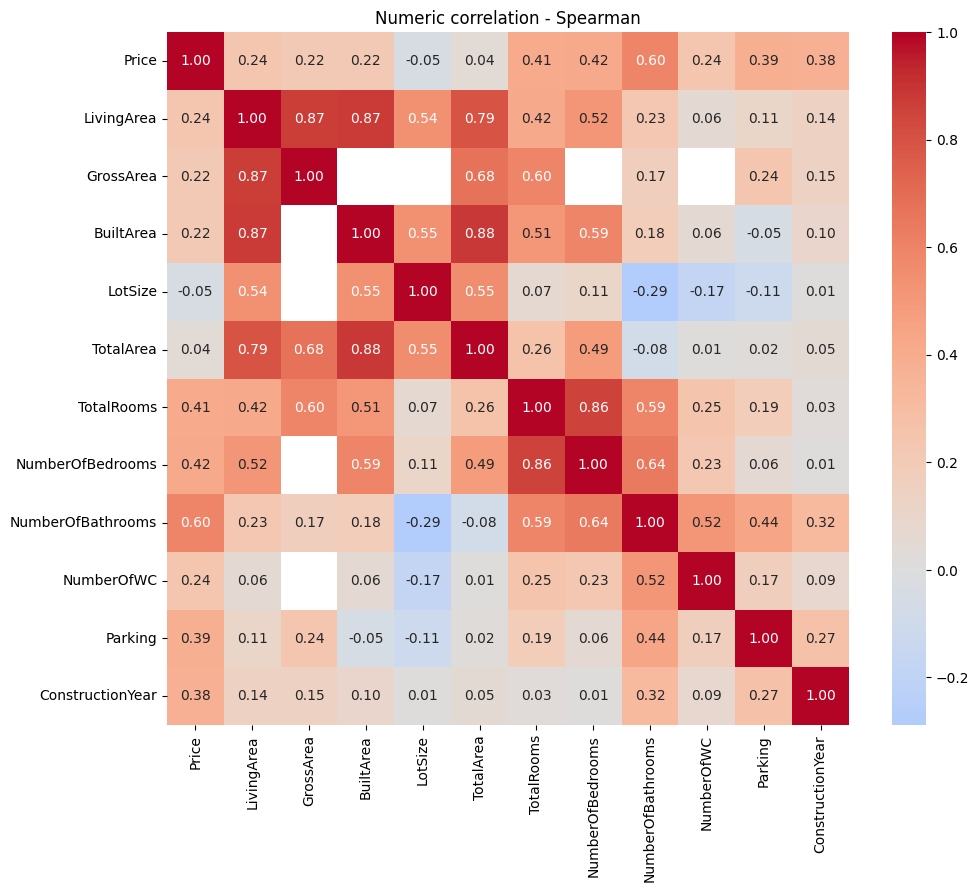

In [48]:
# Realistic price band: drops the corrupt extremes so relationships are clearer
lo, hi = df_train['Price'].quantile([0.01, 0.99])
sane = df_train['Price'].between(lo, hi)
print('Rows in sane subset:', int(sane.sum()), f'({sane.mean()*100:.1f}%)')

# Only the genuinely numeric columns (Floor & EnergyEfficiencyLevel are categorical now)
num = ['Price','LivingArea','GrossArea','BuiltArea','LotSize','TotalArea',
       'TotalRooms','NumberOfBedrooms','NumberOfBathrooms','NumberOfWC',
       'Parking','ConstructionYear']

# Spearman: robust to the area outliers still present and to non-linear relationships
corr = df_train.loc[sane, num].corr(method='spearman', numeric_only=True)
plt.figure(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Numeric correlation - Spearman'); plt.show()

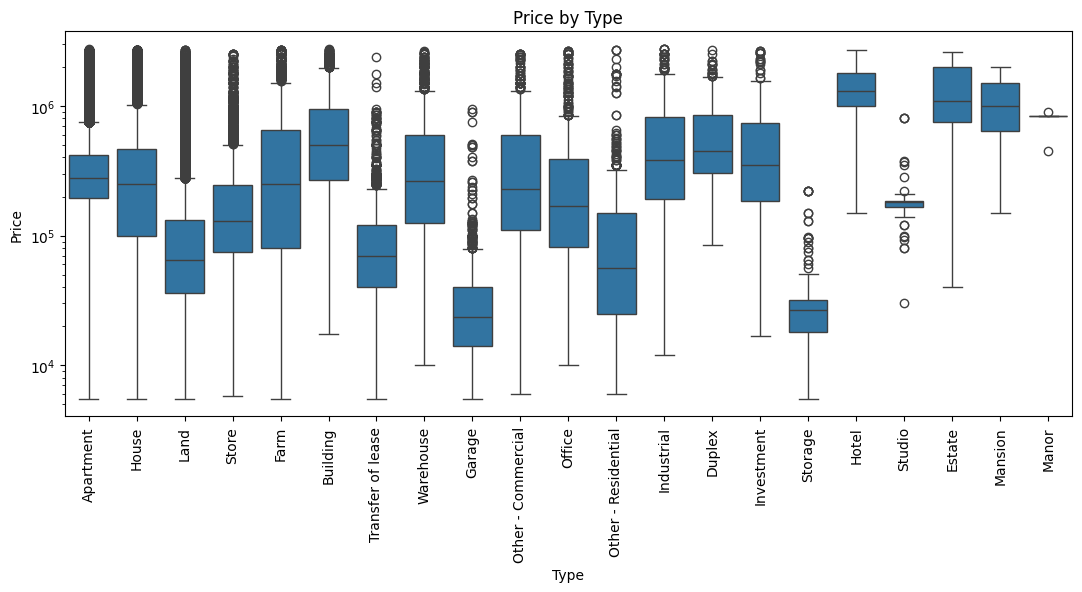

In [45]:
# Price by Type (log axis so the skew doesn't squash the boxes)
order = df_train['Type'].value_counts().index
plt.figure(figsize=(13, 5))
sns.boxplot(data=df_train[sane], x='Type', y='Price', order=order)
plt.yscale('log')
plt.xticks(rotation=90); plt.title('Price by Type'); plt.show()

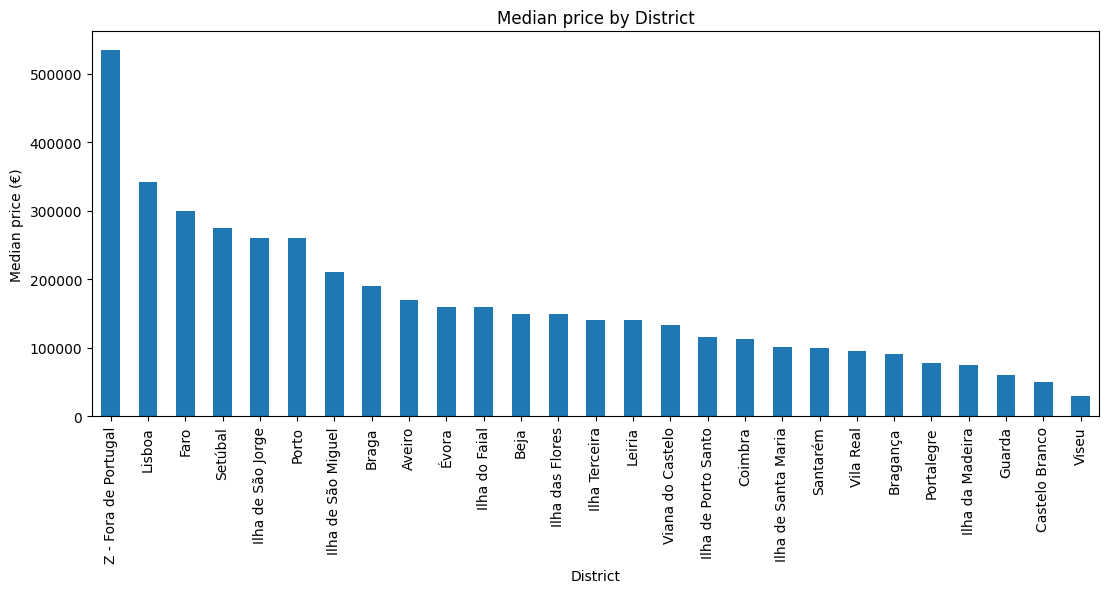

In [46]:
# Median price by District
med = df_train[sane].groupby('District')['Price'].median().sort_values(ascending=False)
med.plot.bar(figsize=(13, 5))
plt.ylabel('Median price (€)'); plt.title('Median price by District'); plt.show()

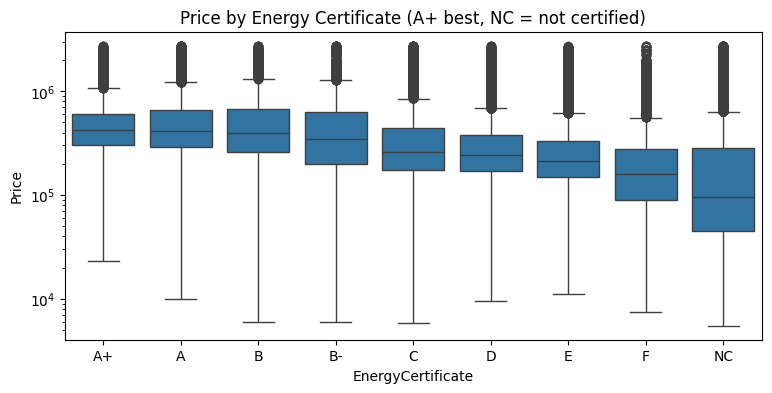

In [47]:
# Price by energy rating — use EnergyCertificate (letters), ordered best -> worst, NC last
order_e = [g for g in ['A+','A','B','B-','C','D','E','F','NC']
           if g in set(df_train['EnergyCertificate'].dropna())]
plt.figure(figsize=(9, 4))
sns.boxplot(data=df_train[sane], x='EnergyCertificate', y='Price', order=order_e)
plt.yscale('log')
plt.title('Price by Energy Certificate (A+ best, NC = not certified)'); plt.show()

**Conclusion** 

Price is most strongly associated with room/bathroom counts (Bathrooms 0.60,
Bedrooms/Rooms 0.42) rather than the area columns, whose price correlation is depressed by
missingness and by pooling all property types. 

The five area columns are highly redundant (0.79–0.88), so a single one (LivingArea, the best-populated) suffices. 

**From the Type Boxplots**: Type spans Hotels/Estates (~1M+) down to Garages/Storage (~25k), confirming cheap listings are real and type-driven; 

**From the Districts Bar Plot**: District shows a clear coastal-vs-interior gradient that also justifies the geographic biased-sample drift scenario. 

**From the EnergyCertificate Boxplots**: EnergyCertificate relates monotonically to price (A+ high, NC low) but is partly confounded with type. 

These results will later inform  feature selection on which variuables are redundant and which variables to keep. 

## Categorical Association - Cramér's V

The Spearman heatmap above only covers numeric features. To measure association between the
**categorical** variables we use Cramér's V, which ranges from 0 (independent) to 1 (perfectly
associated). Unlike correlation it has no direction or sign, it only quantifies how strongly
two categoricals move together.

Two methodological choices:

- **Bias-corrected version.** Plain Cramér's V is inflated when the variables have very
  different numbers of categories (our booleans have 2, District has 27), making high-cardinality
  pairs look artificially strong. The bias-corrected (Bergsma) formula removes that distortion.
- **Low-cardinality columns only.** We exclude City (275) and Town (2 263): their contingency
  tables are huge and slow, and Cramér's V becomes unreliable and inflated with that many sparse
  categories. We keep Type, EnergyCertificate, ConservationStatus, District and the boolean
  amenities.

Each pair is computed only on rows where both columns are present, so pairs involving heavily
missing columns (e.g. ConservationStatus) rest on a smaller subset and should be read with care.
We use this to spot redundant categoricals and to quantify confounding between Type, location and the other categories.

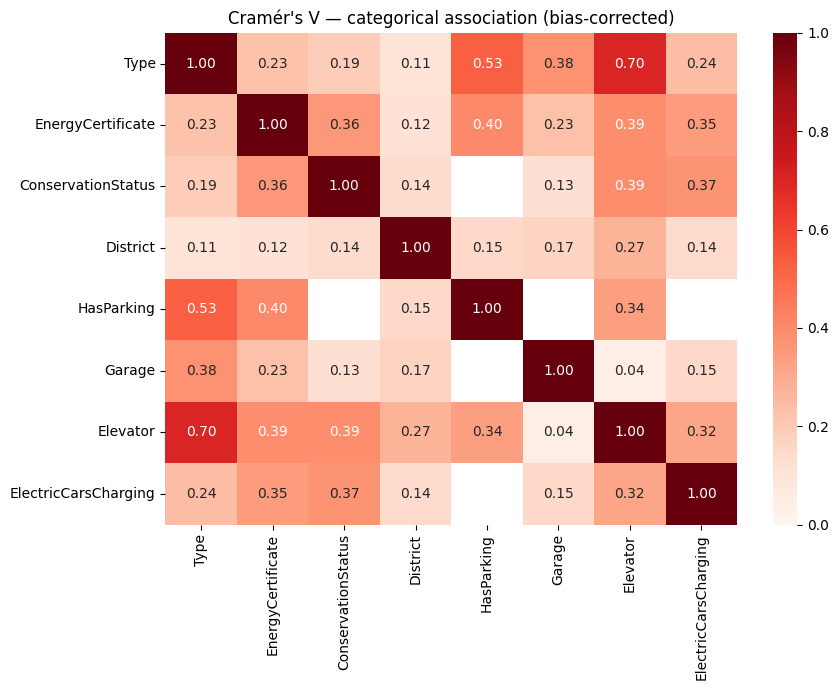

In [ ]:
def cramers_v(x, y):
    """Bias-corrected Cramér's V. Uses only rows where both are non-null."""
    cm = pd.crosstab(x, y)
    if cm.shape[0] < 2 or cm.shape[1] < 2:
        return np.nan
    chi2 = chi2_contingency(cm)[0]
    n = cm.to_numpy().sum()
    if n == 0:
        return np.nan
    phi2 = chi2 / n
    r, k = cm.shape
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    denom = min(kcorr - 1, rcorr - 1)
    if denom <= 0:
        return np.nan
    return np.sqrt(phi2corr / denom)

cat_cols = ['Type', 'EnergyCertificate', 'ConservationStatus', 'District',
            'HasParking', 'Garage', 'Elevator', 'ElectricCarsCharging']

cv = pd.DataFrame(np.eye(len(cat_cols)), index=cat_cols, columns=cat_cols)
for i, a in enumerate(cat_cols):
    for b in cat_cols[i + 1:]:
        v = cramers_v(df_train[a], df_train[b])
        cv.loc[a, b] = cv.loc[b, a] = v

plt.figure(figsize=(9, 7))
sns.heatmap(cv.astype(float), annot=True, fmt='.2f', cmap='Reds', vmin=0, vmax=1)
plt.title("Cramér's V — categorical association (bias-corrected)")
plt.tight_layout(); plt.show()